In [ ]:
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist
from scipy.integrate import trapezoid

import numpy as np
from numpy.random import normal, uniform

import tqdm

import random
from random import randint

import torch
import torch.nn as nn  # <-- this was missing!

In [779]:
# 1) Generate random 2-periodic functions f(x) with f(-1)=f(1)=0
# ------------------------------------------------------------
def random_periodic_function(x, num_terms=2):
    # Randomly select coefficients for sines and cosines
    coeffs = np.random.randn(num_terms)
    freqs = np.ceil(uniform(0,2,num_terms))  # Random frequencies
    function = np.zeros_like(x)
    for i in range(num_terms):
        function += coeffs[i] * np.sin(np.pi * freqs[i] * x)
        function += coeffs[i] * np.cos(np.pi * freqs[i] * x)
    return function


def generate_random_periodic_ics(N, x):
    """
    Generate N random initial conditions on the grid x,
    each 2-periodic and vanishing at x=-1 and x=1.
    Returns an array ICs of shape (N, len(x)).
    """
    Nx = len(x)
    ICs = np.zeros((N, Nx))
    for i in range(N):
        ICs[i,:] = random_periodic_function(x)
    return ICs

# ------------------------------------------------------------
# 2) WENO5 flux splitting for advective derivative d/dx(0.5*u^2)
# ------------------------------------------------------------
def flux_burgers(u):
    """ f(u) = 0.5 * u^2 """
    return 0.5 * u * u

def weno5_fluxsplit(u, dx):
    """
    Compute + d/dx [0.5*u^2] using WENO5 + local Lax-Friedrichs splitting.
    We'll do a standard approach with ghost cells for BC=0 at boundaries.
    Returns an array dfdx of shape (len(u),).
    PDE sign note: for u_t + (f(u))_x = ...,
    we get advTerm = + d/dx f(u).
    """
    N = len(u)
    dfdx = np.zeros(N)

    # wave speed alpha
    alpha = np.max(np.abs(u)) + 1e-14

    # flux splitting
    fp = 0.5 * (flux_burgers(u) + alpha*u)
    fm = 0.5 * (flux_burgers(u) - alpha*u)

    # We'll do a standard 5th-order WENO on each interface
    def weno_reconstruct(vals, i, plus=True):
        """
        Reconstruct flux at interface i from one side (plus or minus).
        Standard WENO5 formula with alpha=some small eps.
        """
        eps = 1e-6
        gamma1, gamma2, gamma3 = 0.1, 0.6, 0.3

        if plus:
            v0, v1, v2, v3, v4 = vals[i-3], vals[i-2], vals[i-1], vals[i], vals[i+1]
        else:
            v0, v1, v2, v3, v4 = vals[i+2], vals[i+1], vals[i], vals[i-1], vals[i-2]

        beta0 = (13/12)*(v0 - 2*v1 + v2)**2 + 0.25*(v0 - 4*v1 + 3*v2)**2
        beta1 = (13/12)*(v1 - 2*v2 + v3)**2 + 0.25*(v1 - v3)**2
        beta2 = (13/12)*(v2 - 2*v3 + v4)**2 + 0.25*(3*v2 - 4*v3 + v4)**2

        alpha0 = gamma1 / ((eps + beta0)**2)
        alpha1 = gamma2 / ((eps + beta1)**2)
        alpha2 = gamma3 / ((eps + beta2)**2)
        s = alpha0 + alpha1 + alpha2
        w0, w1, w2 = alpha0/s, alpha1/s, alpha2/s

        p0 = (1/3)*v0 - (7/6)*v1 + (11/6)*v2
        p1 = (-1/6)*v1 + (5/6)*v2 + (1/3)*v3
        p2 = (1/3)*v2 + (5/6)*v3 - (1/6)*v4

        return w0*p0 + w1*p1 + w2*p2

    # pad with 3 ghost cells using BC=0 => at boundaries
    pad = 3
    up  = np.pad(u,  (pad,pad), mode='constant', constant_values=0.0)
    fpp = np.pad(fp, (pad,pad), mode='constant', constant_values=0.0)
    fpm = np.pad(fm, (pad,pad), mode='constant', constant_values=0.0)

    flux_int = np.zeros(N+1)
    for i in range(1, N):
        fL = weno_reconstruct(fpp, i+pad, plus=True)
        fR = weno_reconstruct(fpm, i+pad, plus=False)
        flux_int[i] = fL + fR
    flux_int[0]   = 0.0
    flux_int[-1]  = 0.0

    for i in range(N):
        dfdx[i] = (flux_int[i+1] - flux_int[i])/dx

    return dfdx

# ------------------------------------------------------------
# 3) Helpers for first/second spatial derivatives
# ------------------------------------------------------------
def first_derivative(u, dx):
    """Compute d/dx of u with central difference (one-sided at boundaries)."""
    N = len(u)
    d1 = np.zeros(N)
    for i in range(1, N-1):
        d1[i] = (u[i+1] - u[i-1])/(2*dx)
    # boundary
    d1[0]  = (u[1]-u[0])/(dx)
    d1[-1] = (u[-1]-u[-2])/(dx)
    return d1

def second_derivative(u, dx):
    """Compute d2/dx2 of u with second difference (approx at boundaries)."""
    N = len(u)
    d2 = np.zeros(N)
    for i in range(1, N-1):
        d2[i] = (u[i+1] - 2*u[i] + u[i-1])/(dx*dx)
    # boundary
    d2[0]  = (u[2] - 2*u[1] + u[0])/(dx*dx)
    d2[-1] = (u[-1] - 2*u[-2] + u[-3])/(dx*dx)
    return d2

# ------------------------------------------------------------
# 4) Main routine: For each of N random ICs => solve PDE => store in solutions
# ------------------------------------------------------------
def main_burgers_random_ics(N=2):
    """
    Generate N random 2-periodic ICs that vanish at x=-1, x=1,
    then solve Burgers eq from t=0 to t=1 with nu=0.001,
    storing solution in 'solutions' of shape (N, M_x, M_t),
    plus the 1st & 2nd derivatives in 'solutions_dx' & 'solutions_dxx'.
    """
    # 1) Grid & parameters
    x_start, x_end = -1.0, 1.0
    dx = 0.001# => 2001 points
    Nx = int((x_end - x_start)/dx) + 1  # Nx=2001
    x = np.linspace(x_start, x_end, Nx)

    dt = 1e-4
    tmax = 1.0
    Nt = int(tmax/dt) + 1  # => 10001 steps

    nu = 0.001

    print(f"Setting up PDE with Nx={Nx}, Nt={Nt}, dx={dx}, dt={dt}, nu={nu}")

    # 2) Generate N random ICs
    ICs = generate_random_periodic_ics(N, x)
    # enforce BC: f(-1)=f(1)=0 is already guaranteed by the sine expansions, but let's set them explicitly
 
    # 3) Prepare the big 3D arrays
    solutions     = np.zeros((N, Nx, Nt), dtype=float)
    solutions_dx  = np.zeros((N, Nx, Nt), dtype=float)
    solutions_dxx = np.zeros((N, Nx, Nt), dtype=float)

    # 4) For each IC, solve PDE, store in solutions[i,:,:]
    t_vals = np.linspace(0, tmax, Nt)  # times

    for i in range(N):
        print(f"Solving PDE for IC #{i+1}/{N} ...")
        # copy the initial condition
        u = ICs[i,:].copy()

        # store t=0 snapshot
        solutions[i, :, 0] = u
        solutions_dx[i, :, 0]  = first_derivative(u, dx)
        solutions_dxx[i, :, 0] = second_derivative(u, dx)

        # time stepping
        t_current = 0.0
        for n in range(1, Nt):
            # (a) advTerm = + d/dx (0.5 u^2)
            advTerm = weno5_fluxsplit(u, dx)

            # (b) diffTerm = nu * d2u/dx2
            diffTerm = np.zeros(Nx)
            for j in range(1, Nx-1):
                diffTerm[j] = nu*(u[j+1] - 2*u[j] + u[j-1])/(dx*dx)

            # PDE => u_t = - advTerm + diffTerm
            # forward Euler
            u_new = u - dt*advTerm + dt*diffTerm

            # enforce BC: Dirichlet => 0
            u_new[0]  = solutions[i,0,0]
            u_new[-1] = solutions[i,-1,0]

            # update
            u = u_new
            t_current += dt

            # store
            solutions[i, :, n]     = u
            solutions_dx[i, :, n]  = first_derivative(u, dx)
            solutions_dxx[i, :, n] = second_derivative(u, dx)

    print("All PDE solves complete. Returning the 3D arrays.")
    return x, t_vals, solutions, solutions_dx, solutions_dxx

In [780]:
N = 10  # number of random ICs
x, t_vals, solutions, solutions_dx, solutions_dxx = main_burgers_random_ics(N=N)

Setting up PDE with Nx=2001, Nt=10001, dx=0.001, dt=0.0001, nu=0.001
Solving PDE for IC #1/10 ...
Solving PDE for IC #2/10 ...
Solving PDE for IC #3/10 ...
Solving PDE for IC #4/10 ...
Solving PDE for IC #5/10 ...
Solving PDE for IC #6/10 ...
Solving PDE for IC #7/10 ...
Solving PDE for IC #8/10 ...
Solving PDE for IC #9/10 ...
Solving PDE for IC #10/10 ...
All PDE solves complete. Returning the 3D arrays.


In [ ]:
#solutions = np.load('solutions.npy')
#solutions_dx = np.load('solutions_dx.npy')
#solutions_dxx = np.load('solutions_dxx.npy')
#solution_true = np.load('solution_true.npy')

In [781]:
mask = ~np.isnan(solutions).any(axis=(1,2)) & ~np.isinf(solutions).any(axis=(1,2))
solutions = solutions[mask]
solutions_dx = solutions_dx[mask]
solutions_dxx = solutions_dxx[mask]

In [5]:
np.save('solutions.npy',solutions)
np.save('solutions_dx.npy',solutions_dx)
np.save('solutions_dxx.npy',solutions_dxx)

In [782]:
M_list = np.linspace(200,1800,9).astype(int)
print(M_list)

def create_shifted_matrix(A, M):
    N, d = A.shape
    B = np.zeros_like(A)  # Initialize B with zeros, same shape as A

    # Shift rows
    for i in range(N):
        new_row = (i + M) % N  # Calculate the new row index with wrapping around
        B[new_row, :] = A[i, :]

    return B

def apply_row_shift_to_tensor(C, M):
    p, N, d = C.shape
    B = np.zeros_like(C)  # Initialize tensor B with zeros, same shape as C

    for i in range(p):
        B[i, :, :] = create_shifted_matrix(C[i, :, :], M)

    return B

[ 200  400  600  800 1000 1200 1400 1600 1800]


In [783]:
solutions_new = np.zeros(((len(M_list)-1)*solutions.shape[0],solutions.shape[1],solutions.shape[2]))
solutions_dx_new = np.zeros(((len(M_list)-1)*solutions.shape[0],solutions.shape[1],solutions.shape[2]))
solutions_dxx_new = np.zeros(((len(M_list)-1)*solutions.shape[0],solutions.shape[1],solutions.shape[2]))

In [784]:
for i in range(len(M_list)-1):
    solutions_new[i*solutions.shape[0]:(i+1)*solutions.shape[0],:,:] = apply_row_shift_to_tensor(solutions,M_list[i])
    solutions_dx_new[i*solutions.shape[0]:(i+1)*solutions.shape[0],:,:] = apply_row_shift_to_tensor(solutions_dx,M_list[i])
    solutions_dxx_new[i*solutions.shape[0]:(i+1)*solutions.shape[0],:,:] = apply_row_shift_to_tensor(solutions_dxx,M_list[i])

In [785]:
solutions = np.vstack((solutions,solutions_new))
solutions_dx = np.vstack((solutions_dx,solutions_dx_new))
solutions_dxx = np.vstack((solutions_dxx,solutions_dxx_new))

In [202]:
def burgers_true():

    # 1) Grid & parameters
    x_start, x_end = -1.0, 1.0
    dx = 1*1e-3        # => 2001 points
    Nx = int((x_end - x_start)/dx) + 1  # Nx=2001
    x = np.linspace(x_start, x_end, Nx)

    dt = 1*1e-4
    tmax = 1.0
    Nt = int(tmax/dt) + 1  # => 10001 steps

    nu = 0.0001

    print(f"Setting up PDE with Nx={Nx}, Nt={Nt}, dx={dx}, dt={dt}, nu={nu}")

    # 2) Generate N random ICs
    ICs = -np.sin(np.pi*(x))
    # enforce BC: f(-1)=f(1)=0 is already guaranteed by the sine expansions, but let's set them explicitly
    ICs[0]  = 0.0
    ICs[-1] = 0.0

    # 3) Prepare the big 3D arrays
    solutions     = np.zeros((Nx, Nt), dtype=float)
    solutions_dx  = np.zeros((Nx, Nt), dtype=float)
    solutions_dxx = np.zeros((Nx, Nt), dtype=float)

    # 4) For each IC, solve PDE, store in solutions[i,:,:]
    t_vals = np.linspace(0, tmax, Nt)  # times


    u = ICs.copy()

    # store t=0 snapshot
    solutions[:, 0] = u
    solutions_dx[:, 0]  = first_derivative(u, dx)
    solutions_dxx[:, 0] = second_derivative(u, dx)

    # time stepping
    t_current = 0.0
    for n in range(1, Nt):
        # (a) advTerm = + d/dx (0.5 u^2)
        advTerm = weno5_fluxsplit(u, dx)

        # (b) diffTerm = nu * d2u/dx2
        diffTerm = np.zeros(Nx)
        for j in range(1, Nx-1):
            diffTerm[j] = nu*(u[j+1] - 2*u[j] + u[j-1])/(dx*dx)

        # PDE => u_t = - advTerm + diffTerm
        # forward Euler
        u_new = u - dt*advTerm + dt*diffTerm

        # enforce BC: Dirichlet => 0
        u_new[0]  = 0.0
        u_new[-1] = 0.0

        # update
        u = u_new
        t_current += dt

        # store
        solutions[:, n]     = u
        solutions_dx[:, n]  = first_derivative(u, dx)
        solutions_dxx[:, n] = second_derivative(u, dx)

    print("All PDE solves complete. Returning the 3D arrays.")
    return x, t_vals, solutions, solutions_dx, solutions_dxx

Setting up PDE with Nx=2001, Nt=10001, dx=0.001, dt=0.0001, nu=0.0001
All PDE solves complete. Returning the 3D arrays.


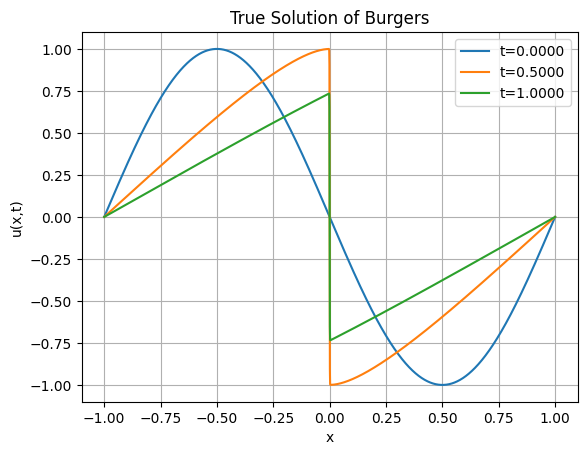

In [203]:
_, _, solution_true, solution_true_dx,solution_true_dxx = burgers_true()

plt.figure()
# pick 3 time snapshots
idx_times = [0, int(len(t_vals)/2), len(t_vals)-1]
for idx in idx_times:
    plt.plot(x, solution_true[:, idx], label=f"t={t_vals[idx]:.4f}")
plt.title(f"True Solution of Burgers")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True)
plt.legend()
plt.show()

In [1086]:
#np.save('solutions.npy',solutions)
#np.save('solutions_dx.npy',solutions_dx)
#np.save('solutions_dxx.npy',solutions_dxx)
np.save('solution_true',solution_true)

In [786]:
U_sol = solutions[:,:,:]
Ux = solutions_dx[:,1:-1,:]
Uxx = solutions_dxx[:,1:-1,:]

In [14]:
solution_true[None,:,:].shape

(1, 2001, 10001)

In [787]:
#Construct empirical kernel

def compute_empirical_kernels_mixed(u_samples, ux_int, lap_int):
    K = u_samples @ u_samples.T

    K_x = ux_int @ u_samples.T
    LapK_x = lap_int @ u_samples.T

    K_y = u_samples @ ux_int.T
    LapK_y = u_samples @ lap_int.T

    K_xy = ux_int @ ux_int.T

    LapK_xy = lap_int @ lap_int.T

    LapK_y_x = lap_int @ ux_int.T

    LapK_x_y = ux_int @ lap_int.T

    K_Empirical = np.block([
    [K,         K_y,        LapK_y],
    [K_x,      K_xy,     LapK_x_y],
    [LapK_x,    LapK_y_x, LapK_xy]])

    return K_Empirical

In [788]:
#np.random.seed(0)

N_domain_tot = Ux.shape[1]
N_boundary_tot = 2
N = N_domain_tot + N_boundary_tot
#Boundary and interior

X_domain_tot = x[1:-1]
X_boundary_tot = np.array([-1,1])

K_Empirical = np.zeros((2*N_domain_tot+N,2*N_domain_tot+N))

N_solutions = U_sol.shape[0]


for i in range(N_solutions):
  K_Empirical += compute_empirical_kernels_mixed(U_sol[i,:,:],Ux[i,:,:],Uxx[i,:,:])

In [789]:
#Maximin ordering

def maximin(x):
  init_indices = np.arange(len(x[:,0]))[:,None]

  x = np.concatenate((x,init_indices),axis=1)
  indices = np.copy(init_indices)

  #Select arbitrary index to start (here 0)
  indices[0] = 0
  A = x[indices[0],:-1]

  x = np.delete(x,indices[0],axis=0)

  for i in range(1,len(indices)):
    maximizer = np.argmax(cdist(x[:,:-1],A).min(axis=1))
    indices[i] =x[int(maximizer),:][1]
    A = np.vstack([A,x[int(maximizer),:-1]])
    x = np.delete(x,int(maximizer),axis=0)

  return indices.reshape(-1)

#Permutation map

P = np.zeros(2*N_domain_tot+N)

grid = np.vstack([X_domain_tot[:,None], X_boundary_tot[:,None]])

P[:N] = maximin(grid).astype(int)

#Identity map for derivative measurements
ord = np.arange(N_domain_tot)

P[N:] = np.hstack([ord,ord])

#Lengthscale of x
def lengthscale(x):
  lengths = np.ones(len(x[:,0]))
  lengths[0] = float('inf')

  for i in range(1,len(x[:,0])):
    lengths[i] = np.min(cdist(np.array([x[i,:]]),x[:i,:]))

  return lengths

grid_reordered = grid[maximin(grid)]

In [ ]:
def kernel_u(s,t,params):
  #K = -(s-t)*kernel(s,t,params)/params[0]**2
  K = -5*(s-t)*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(params[0]+jnp.sqrt(5)*jnp.abs(s-t))/(3*params[0]**3)
  return K

def kernel_z(s,t,params):
  #K = (s-t)*kernel(s,t,params)/params[0]**2
  K = 5*(s-t)*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(params[0]+jnp.sqrt(5)*jnp.abs(s-t))/(3*params[0]**3)
  return K

def kernel_uz(s,t,params):
  #K = (params[0]**2-(s-t)**2)*kernel(s,t,params)/params[0]**4
  K = 5*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(jnp.sqrt(5)*params[0]*jnp.abs(s-t)+params[0]**2-5*(s-t)**2)/(3*params[0]**4)
  return K

def kernel_uuz(s,t,params):
  #K = (s-t)*((s-t)**2-3*params[0]**2)*kernel(s,t,params)/params[0]**6
  K = 25*(s-t)*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(jnp.sqrt(5)*jnp.abs(s-t)-3*params[0])/(3*params[0]**5)
  return K

def kernel_uzz(s,t,params):
  #K = -(s-t)*((s-t)**2-3*params[0]**2)*kernel(s,t,params)/params[0]**6
  K = -25*(s-t)*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(jnp.sqrt(5)*jnp.abs(s-t)-3*params[0])/(3*params[0]**5)
  return K

def kernel_uu(s,t,params):
  #K = ((s-t)**2-params[0]**2)*kernel(s,t,params)/params[0]**4
  K =  -5*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(jnp.sqrt(5)*params[0]*jnp.abs(s-t)+params[0]**2-5*(s-t)**2)/(3*params[0]**4)
  return K

def kernel_zz(s,t,params):
  #K = ((s-t)**2-params[0]**2)*kernel(s,t,params)/params[0]**4
  K =  -5*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(jnp.sqrt(5)*params[0]*jnp.abs(s-t)+params[0]**2-5*(s-t)**2)/(3*params[0]**4)
  return K

def kernel_uuzz(s,t,params):
  #K = kernel(s,t,params)*(3*params[0]**4-6*params[0]**2*(s-t)**2+(s-t)**4)/params[0]**8
  K = -25*jnp.exp(-jnp.sqrt(5)*jnp.abs(s-t)/params[0])*(5*jnp.sqrt(5)*params[0]*jnp.abs(s-t)-(3*params[0]**2+5*(s-t)**2))/(3*params[0]**6)
  return K

In [1411]:
Theta = np.zeros((N + 2 * N_domain_tot, N + 2 * N_domain_tot))

Theta[:N, :N] = K_Empirical[P[:N].astype(int)][:, P[:N].astype(int)]
Theta[N:, N:] = K_Empirical[N:, N:]
Theta[N:, :N] = K_Empirical[N:, P[:N].astype(int)]
Theta[:N, N:] = Theta[N:, :N].T

Theta = Theta / (N *solutions.shape[2])

trace1 = np.trace(Theta[:N, :N])
trace2 = np.trace(Theta[N:N + N_domain_tot, N:N + N_domain_tot])
trace3 = np.trace(Theta[N + N_domain_tot:N + 2 * N_domain_tot, N + N_domain_tot:N + 2 * N_domain_tot])

ratio = trace2 / trace1
ratio2 = trace3 / trace1

nugget = 6*1e-7

temp = np.concatenate((np.ones((1, N)),
                       ratio * np.ones((1, N_domain_tot)),
                       ratio2 * np.ones((1, N_domain_tot))), axis=1)
Theta = Theta + nugget * np.diag(temp[0])

# -----------------------------
# 2) Lengthscales
# -----------------------------
l = lengthscale(grid_reordered)  # lengthscale should return a numpy array
l_extended = np.hstack([l, l[-1] * np.ones(2 * N_domain_tot)])

# -----------------------------
# 3) Sparsity set functions
# -----------------------------
def sparsity_set(x, rho):
    # Reorder x according to maximin(x)
    x = x[maximin(x)]
    dist = cdist(x, x)
    # Broadcast the lengthscale computed from x to a full matrix.
    rhol = rho * np.broadcast_to(lengthscale(x), (x.shape[0], x.shape[0]))
    arg = np.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]

def sparsity_extended(x, rho):
    # extender: indices from P[N:] cast to int
    extender = x[P[N:].astype(int)]
    x = x[maximin(x)]
    x = np.vstack([x, extender])
    dist = cdist(x, x)
    rhol = rho * np.broadcast_to(l_extended, (x.shape[0], x.shape[0]))
    arg = np.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]

# -----------------------------
# 4) Sparsity parameter rho and computing sparsity set S
# -----------------------------
rho = 3
S = sparsity_extended(grid, rho)

def card(j):
    s_j = S[S[:, 1] == j][:, 0]
    cardinality = len(s_j)
    return s_j, cardinality

U = np.zeros((N + 2 * N_domain_tot, N + 2 * N_domain_tot))

for j in tqdm.tqdm(range(N + 2 * N_domain_tot)):
    s_j, cardinality = card(j)
    # Use np.ix_ to index rows and columns from s_j
    Theta_redux = np.linalg.inv(Theta[np.ix_(s_j, s_j)])
    denom = np.sqrt(Theta_redux[-1, -1])
    U[s_j, j] = Theta_redux[:, -1] / denom

100%|██████████| 5999/5999 [00:00<00:00, 6006.35it/s]


In [1412]:
#Putting all the pieces together
Permute = np.zeros((N+2*N_domain_tot,N+2*N_domain_tot))

combo = np.concatenate((P[:N].astype(int)[:,None],np.arange(N).astype(int)[:,None]),axis=1)

Permute[combo[:,1],combo[:,0]] = 1

Permute[N:,N:] = np.eye(2*N_domain_tot)

#K_inv_red = Permute.T@U@U.T@Permute

L_ROM = U.T@Permute

In [1413]:
#L_ROM = np.linalg.cholesky(np.linalg.inv(Theta+(2*10**-5)*np.eye(Theta.shape[0])))

In [1414]:
L_UT = L_ROM.shape[0]*(L_ROM.shape[0]+1)/2
print(f"The proportion of nonzero entries in the lower triangular part is {np.count_nonzero(L_ROM)/L_UT}")

The proportion of nonzero entries in the lower triangular part is 0.0029003722842696005


In [1415]:
np.max(L_ROM)

np.float64(922.1544634772374)

In [1416]:
#Check L_ROM does not contain inf values
if np.max(L_ROM)==(np.inf or np.nan):
    print("Pick a higher regularization term for empirical kernel matrix")
else:
    print("The empirical kernel is ready to use")

The empirical kernel is ready to use


In [1417]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


L_ROM_dense = torch.from_numpy(L_ROM).float().to(device)
indices = torch.nonzero(L_ROM_dense, as_tuple=False).t()
values = L_ROM_dense[indices[0], indices[1]]
L_ROM_sparse = torch.sparse_coo_tensor(indices, values, L_ROM_dense.size(), device=device)
L_ROM_sparse = L_ROM_sparse.coalesce()

In [1432]:
nu = 1e-4

# Assume L_ROM_np, N_domain_tot, N_boundary_tot, N, X_domain_tot, and grid are defined.
# For example, if not defined, you could define:
# N_domain_tot = 40
# N_boundary_tot = 10
# N = 50
# N_total = N + 2*N_domain_tot
# X_domain_tot = np.linspace(-1, 1, N_domain_tot)  # example
# grid = ... (your grid data)

# Convert your original L_ROM (a numpy array) to a PyTorch sparse tensor in float32.

print("Number of nonzeros in L_ROM_sparse:", L_ROM_sparse._nnz())

# -----------------------------------

def J_ROM(v, bdy_g, L, u0, u1, u2, dt=0.01):
    """
    Loss function J_ROM.
    v: tensor of shape (2*N_domain_tot,)
    bdy_g: tensor of shape (N_boundary_tot,)
    L: sparse matrix of shape (N_total, N_total)
    u0, u1, u2: tensors of shape (N_domain_tot,)
    """
    # Ensure inputs are float32.
    v = v.float()
    bdy_g = bdy_g.float()
    u0 = u0.float()
    u1 = u1.float()
    u2 = u2.float()

    # Partition v.
    v0 = v[:N_domain_tot]
    v1 = v[N_domain_tot:2*N_domain_tot]
    # Compute v2.
    v2 = 2/nu * ((v0 - u0)/dt + 0.5*(v0*v1 + u0*u1)) - u2
    # Construct vv = [v0, bdy_g, v1, v2].
    vv = torch.cat((v0, bdy_g, v1, v2), dim=0)  # shape: (N_total,)
    # Multiply L (sparse) with vv.
    temp = torch.sparse.mm(L, vv.unsqueeze(1))  # shape: (N_total, 1)
    temp = temp.squeeze(1)
    return torch.dot(temp, temp)

def grad_J_ROM_torch(v, bdy_g, L, u0, u1, u2, dt=0.01):
    v = v.clone().detach().requires_grad_(True)
    loss = J_ROM(v, bdy_g, L, u0, u1, u2, dt)
    grad_v, = torch.autograd.grad(loss, v, create_graph=False)
    return grad_v

def Hessian_GN_ROM(v, L, dt=0.01):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    total_rows = N + 2 * N_domain_tot  # should equal N_total = 2999.
    mtx = torch.zeros((total_rows, 2 * N_domain_tot), dtype=v.dtype, device=v.device)
    v0 = v[:N_domain_tot]
    v1 = v[N_domain_tot:2*N_domain_tot]
    
    I = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)
    mtx1_left = (2/nu) * (I/dt + 0.5 * torch.diag(v1))
    mtx1_right = (1/nu) * torch.diag(v0)
    mtx1 = torch.cat((mtx1_left, mtx1_right), dim=1)  # shape: (N_domain_tot, 2*N_domain_tot)
    
    mtx[:N_domain_tot, :N_domain_tot] = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)
    mtx[N:N+N_domain_tot, N_domain_tot:2*N_domain_tot] = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)
    mtx[N+N_domain_tot:N+2*N_domain_tot, :] = mtx1
    
    S = torch.sparse.mm(L, mtx)
    return 2 * (S.t() @ S)

# -----------------------------
# 4. Gauss–Newton PDE solver using the sparse L_ROM.
def pde_solver_ROM(max_iter, step_size, initial_sol, u0, u1, u2, L_sparse, dt=0.01):
    """
    Gauss–Newton solver for the reduced-order model PDE using a sparse L_ROM.
    """
    bdy_g = torch.zeros(N_boundary_tot, device=initial_sol.device).float()
    sol = initial_sol.clone().detach().float()
    J_hist = []
    
    J_now = J_ROM(sol, bdy_g, L_sparse, u0, u1, u2, dt)
    J_hist.append(J_now.item())
    print('iter = 0', 'J =', J_now.item())
    
    for iter_step in range(1, max_iter+1):
        H = Hessian_GN_ROM(sol, L_sparse, dt)
        grad_val = grad_J_ROM_torch(sol, bdy_g, L_sparse, u0, u1, u2, dt)
        delta = torch.linalg.solve(H, grad_val)
        sol = sol - step_size * delta
        J_now = J_ROM(sol, bdy_g, L_sparse, u0, u1, u2, dt)
        loss_val = J_now.item()
        if not np.isfinite(loss_val):
            raise ValueError(f"Loss is not finite at iteration {iter_step} (loss = {loss_val}). Aborting.")
        J_hist.append(loss_val)
        print(f'iter = {iter_step}, Gauss-Newton step size = {step_size}, J = {loss_val}')

    
    return sol, J_hist, L_sparse

# -----------------------------
# 5. Example usage in a time-stepping loop.
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    L_ROM_dense = torch.from_numpy(L_ROM).float().to(device)
    indices = torch.nonzero(L_ROM_dense, as_tuple=False).t()
    values = L_ROM_dense[indices[0], indices[1]]
    L_ROM_sparse = torch.sparse_coo_tensor(indices, values, L_ROM_dense.size(), device=device)
    L_ROM_sparse = L_ROM_sparse.coalesce()
    
    # Use our global parameters from above.
    # N_total should be 2999.
    print("Expected L_ROM shape:", (N + 2 * N_domain_tot, N + 2 * N_domain_tot))
    
    # Example initial solution vector v of shape (2*N_domain_tot,)
    initial_sol = torch.randn(2 * N_domain_tot, dtype=torch.float32, device=device)
    # Example data vectors u0, u1, u2 each of shape (N_domain_tot,)
    u0 = torch.randn(N_domain_tot, dtype=torch.float32, device=device)
    u1 = torch.randn(N_domain_tot, dtype=torch.float32, device=device)
    u2 = torch.randn(N_domain_tot, dtype=torch.float32, device=device)
    
    max_iter = 5
    step_size = 0.9

    M_t = 21
    dt = 1/(M_t-1)

    # u_approx will store solutions over time, shape: (2*N_domain_tot, M_t)
    u_approx = torch.zeros((2 * N_domain_tot, M_t), dtype=torch.float32, device=device)
    
    # Suppose X_domain_tot is defined as a NumPy array for the domain.
    # For example:
    X_domain_tot = x[1:-1]
    torch_X = torch.from_numpy(X_domain_tot).float().to(device)
    
    u_approx[:N_domain_tot, 0] = -torch.sin(torch.pi * torch_X)
    u_approx[N_domain_tot:, 0] = -torch.pi * torch.cos(torch.pi * torch_X)
    
    # Set initial u0, u1, u2 from the first time snapshot.
    u0 = u_approx[:N_domain_tot, 0].clone()
    u1 = u_approx[N_domain_tot:2*N_domain_tot, 0].clone()
    u2 = (torch.pi**2) * torch.sin(torch.pi * torch_X)
    
    for i in tqdm.tqdm(range(M_t-1)):
        old_u0 = u0.clone()
        old_u1 = u1.clone()
        old_u2 = u2.clone()
        initial_sol = u_approx[:, i].clone()
        u_next, J_hist, L_Empirical = pde_solver_ROM(max_iter, step_size, initial_sol, u0, u1, u2, L_ROM_sparse, dt=dt)
        u_approx[:, i+1] = u_next.clone()
        u0 = u_approx[:N_domain_tot, i+1].clone()
        u1 = u_approx[N_domain_tot:2*N_domain_tot, i+1].clone()
        u2 = 2/nu * ((u0 - old_u0)/dt + 0.5*(u0*u1 + old_u0*old_u1)) - old_u2

    # Optionally, do something with u_approx, e.g. plot or save.

Number of nonzeros in L_ROM_sparse: 52198
Expected L_ROM shape: (5999, 5999)


  0%|          | 0/20 [00:00<?, ?it/s]

iter = 0 J = 1648329728.0
iter = 1, Gauss-Newton step size = 0.9, J = 16503572.0
iter = 2, Gauss-Newton step size = 0.9, J = 165146.171875
iter = 3, Gauss-Newton step size = 0.9, J = 1738.92724609375
iter = 4, Gauss-Newton step size = 0.9, J = 100.86392211914062


  5%|▌         | 1/20 [00:00<00:03,  5.08it/s]

iter = 5, Gauss-Newton step size = 0.9, J = 82.4851303100586
iter = 0 J = 1641615360.0
iter = 1, Gauss-Newton step size = 0.9, J = 16397368.0
iter = 2, Gauss-Newton step size = 0.9, J = 164118.3125
iter = 3, Gauss-Newton step size = 0.9, J = 2175.28515625
iter = 4, Gauss-Newton step size = 0.9, J = 2003.8726806640625


...

 90%|█████████ | 18/20 [00:02<00:00,  8.59it/s]

iter = 4, Gauss-Newton step size = 0.9, J = 51849.8828125
iter = 5, Gauss-Newton step size = 0.9, J = 51845.32421875
iter = 0 J = 265437232.0
iter = 1, Gauss-Newton step size = 0.9, J = 2033769.0
iter = 2, Gauss-Newton step size = 0.9, J = 69177.65625
iter = 3, Gauss-Newton step size = 0.9, J = 49549.9921875
iter = 4, Gauss-Newton step size = 0.9, J = 49353.71875
iter = 5, Gauss-Newton step size = 0.9, J = 49351.76171875
iter = 0 J = 285891936.0
iter = 1, Gauss-Newton step size = 0.9, J = 6937689.0
iter = 2, Gauss-Newton step size = 0.9, J = 147970.5625


 95%|█████████▌| 19/20 [00:02<00:00,  8.41it/s]

iter = 3, Gauss-Newton step size = 0.9, J = 46528.65234375
iter = 4, Gauss-Newton step size = 0.9, J = 45427.734375
iter = 5, Gauss-Newton step size = 0.9, J = 45416.55859375
iter = 0 J = 320758048.0
iter = 1, Gauss-Newton step size = 0.9, J = 2343761.75
iter = 2, Gauss-Newton step size = 0.9, J = 71087.59375
iter = 3, Gauss-Newton step size = 0.9, J = 43610.6796875
iter = 4, Gauss-Newton step size = 0.9, J = 43332.50390625
iter = 5, Gauss-Newton step size = 0.9, J = 43329.7265625


100%|██████████| 20/20 [00:02<00:00,  8.17it/s]


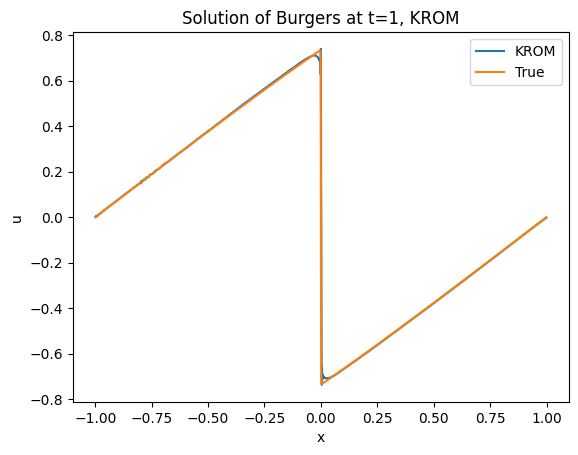

In [1434]:
plt.plot(X_domain_tot,u_approx.cpu().detach().numpy()[:N_domain_tot,-1])
plt.plot(X_domain_tot,solution_true[1:-1,10000])
plt.title('Solution of Burgers at t=1, KROM')
plt.xlabel('x')
plt.ylabel('u')
plt.legend(['KROM','True'])
plt.show()

In [1420]:
end_approx = u_approx[:N_domain_tot,-1].cpu().detach().numpy()

end_error = np.linalg.norm(end_approx-solution_true[1:-1,-1])/np.linalg.norm(solution_true[1:-1,-1])

print(f'The relative error at final time t=1 is {end_error}')

The relative error at final time t=1 is 0.06949607192666145
